In [7]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [8]:

# Read the CSV file into a DataFrame
df = pd.read_csv('Data_Cleaned.csv')


In [9]:
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310176 entries, 0 to 310175
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   District           310176 non-null  object        
 1   Local Time         310176 non-null  datetime64[ns]
 2   UTC Time           310176 non-null  object        
 3   City               310176 non-null  object        
 4   Country Code       310176 non-null  object        
 5   Timezone           310176 non-null  object        
 6   AQI                310176 non-null  int64         
 7   CO                 310176 non-null  float64       
 8   NO2                310176 non-null  float64       
 9   O3                 310176 non-null  float64       
 10  PM25               310176 non-null  float64       
 11  SO2                310176 non-null  float64       
 12  Clouds             310176 non-null  float64       
 13  Precipitation      310176 non-null  float64 

### 3.2. Chỉ số chất lượng không khí (AQI)

In [15]:
# 1) Đảm bảo cột thời gian là datetime
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")

# 2) Trung bình theo giờ toàn Hà Nội (giữ 'Local Time' là CỘT)
df_mean = (
    df.groupby("Local Time", as_index=False)["AQI"].mean()
    .sort_values("Local Time")
)

# 3) Rolling mean 3 ngày (24*3 giờ)
df_mean["AQI_rolling"] = (
    df_mean["AQI"].rolling(window=24*3, center=True, min_periods=24).mean()
)
out = df_mean.dropna(subset=["AQI_rolling"])


 3.2.1. AQI theo giờ của Hà Nội trong suốt cả năm

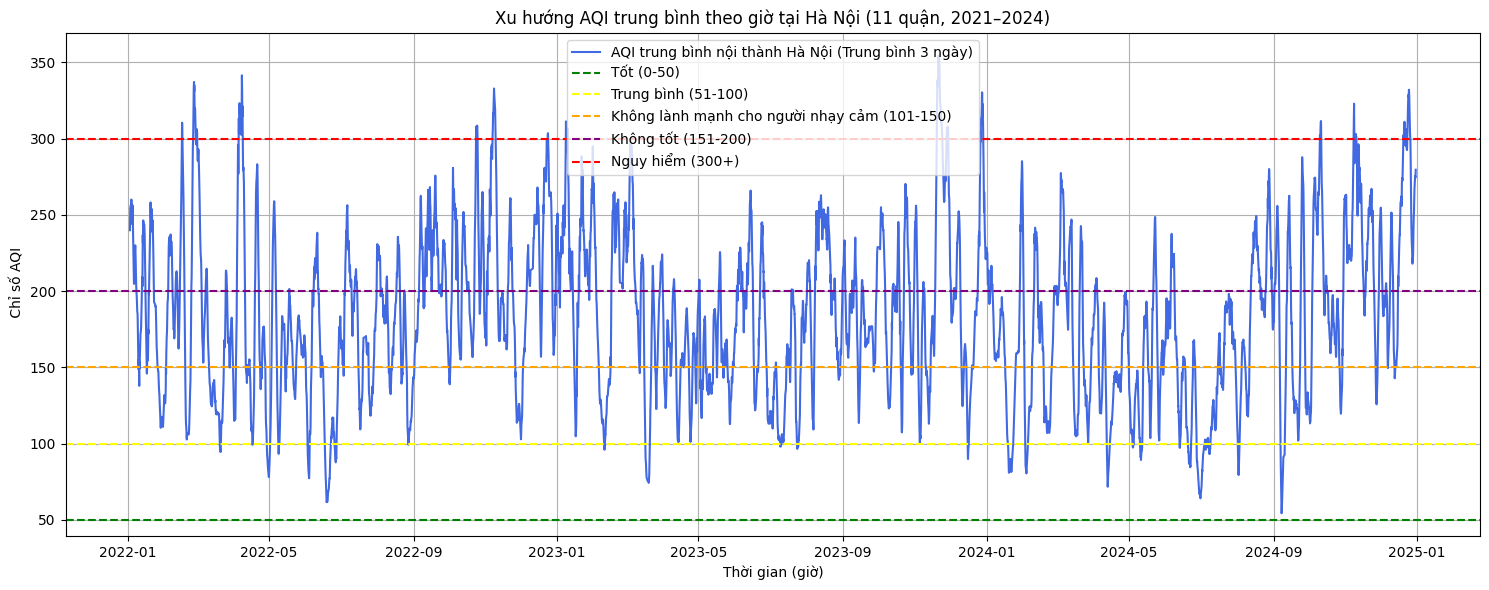

In [ ]:


plt.figure(figsize=(15,6))
plt.plot(out.index, out['AQI_rolling'], color='royalblue', linewidth=1.5, label='AQI trung bình nội thành Hà Nội (Trung bình 3 ngày)')
plt.axhline(50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(100, color='yellow', linestyle='--', label='Trung bình (51-100)')
plt.axhline(150, color='orange', linestyle='--', label='Không lành mạnh cho người nhạy cảm (101-150)')
plt.axhline(200, color='purple', linestyle='--', label='Không tốt (151-200)')
plt.axhline(300, color='red', linestyle='--', label='Nguy hiểm (300+)')
plt.title("Xu hướng AQI trung bình theo giờ tại Hà Nội (11 quận, 2021–2024)")
plt.xlabel("Thời gian (giờ)")
plt.ylabel(" Chỉ số AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3.2.2. AQI theo giờ của Hà Nội trong nhiều tháng với mức AQI nguy hiểm

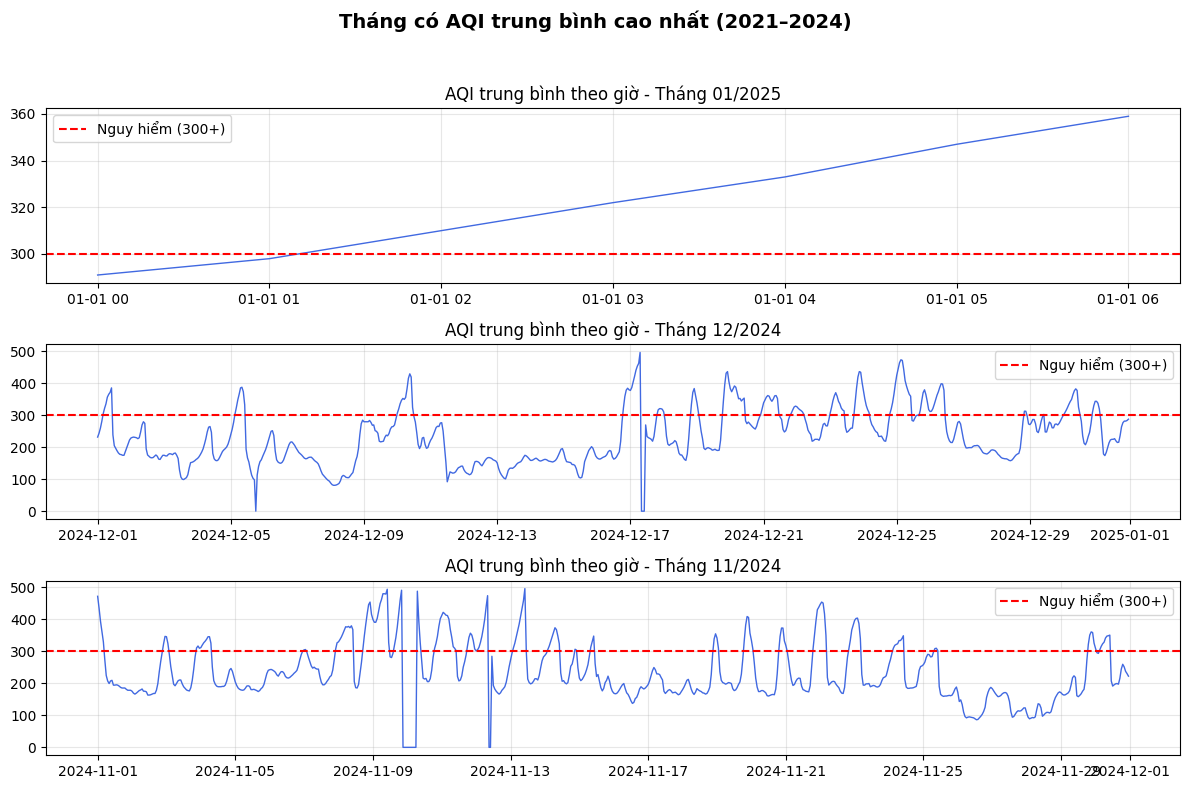

In [19]:


# Thêm Year/Month để lọc theo tháng
df_mean["Year"]  = df_mean["Local Time"].dt.year
df_mean["Month"] = df_mean["Local Time"].dt.month

# Tìm các (Year, Month) có ÍT NHẤT một giờ AQI >= 300
# Lấy 3 tháng có AQI trung bình cao nhất
top_months = (
    df_mean.groupby(["Year","Month"])["AQI"]
    .mean()
    .reset_index()
    .sort_values("AQI", ascending=False)
    .head(3)
)

n = len(top_months)

fig, axs = plt.subplots(n, 1, figsize=(12, 8), squeeze=False)
axs = axs.ravel()

for ax, (_, row) in zip(axs, top_months.iterrows()):
    year, month = int(row["Year"]), int(row["Month"])
    data = df_mean[(df_mean["Year"] == year) & (df_mean["Month"] == month)]
    ax.plot(data["Local Time"], data["AQI"], color="royalblue", lw=1)
    ax.axhline(300, color="red", ls="--", label="Nguy hiểm (300+)")
    ax.set_title(f"AQI trung bình theo giờ - Tháng {month:02d}/{year}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Tháng có AQI trung bình cao nhất (2021–2024)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310176 entries, 0 to 310175
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   District           310176 non-null  object        
 1   Local Time         310176 non-null  datetime64[ns]
 2   UTC Time           310176 non-null  object        
 3   City               310176 non-null  object        
 4   Country Code       310176 non-null  object        
 5   Timezone           310176 non-null  object        
 6   AQI                310176 non-null  int64         
 7   CO                 310176 non-null  float64       
 8   NO2                310176 non-null  float64       
 9   O3                 310176 non-null  float64       
 10  PM25               310176 non-null  float64       
 11  SO2                310176 non-null  float64       
 12  Clouds             310176 non-null  float64       
 13  Precipitation      310176 non-null  float64      